# Superstore Sales Analysis

Exploratory analysis of the Superstore sales dataset: sales by category, monthly sales trend, profit by region, a category/sub-category heatmap, and the top 10 products by profit.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/cleaned/Himanshu_clean.csv', encoding='latin-1')
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
print('Shape:', df.shape)
df.head()

Shape: (9994, 22)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin
0,1,CA-2016-152156,2016-08-11,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.00%
1,2,CA-2016-152156,2016-08-11,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.00%
2,3,CA-2015-113110,2016-12-06,16-06-2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.00%
3,4,US-2015-108966,2015-11-10,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,0.05%
4,5,US-2015-108966,2015-11-10,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.89%


## Total Sales by Category

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


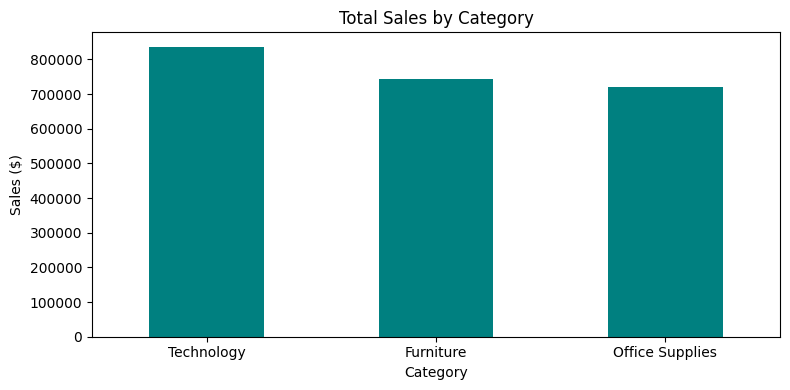

In [2]:
sales_by_cat = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(sales_by_cat)

sales_by_cat.plot(kind='bar', color='teal', figsize=(8, 4))
plt.title('Total Sales by Category')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/sales_by_category.png')
plt.show()

## Monthly Sales Trend

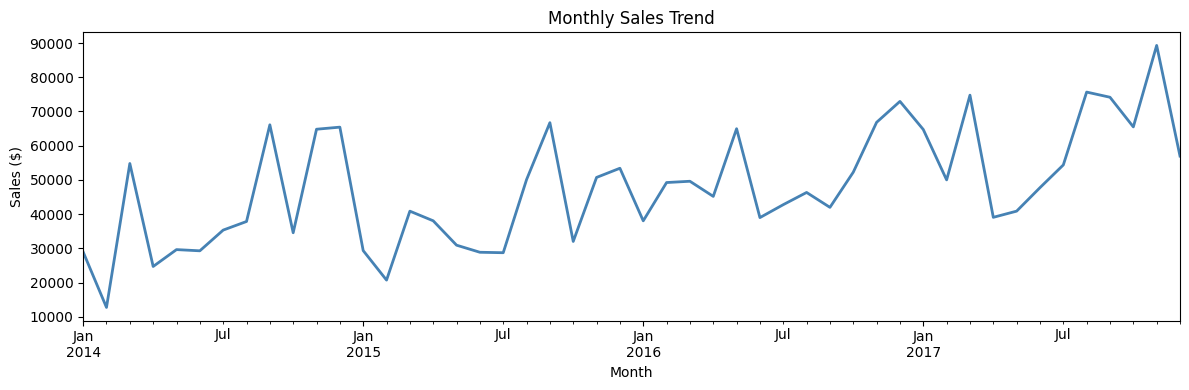

In [3]:
monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum()

monthly_sales.plot(figsize=(12, 4), color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend')
plt.ylabel('Sales ($)')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('outputs/monthly_trend.png')
plt.show()

## Total Profit by Region

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


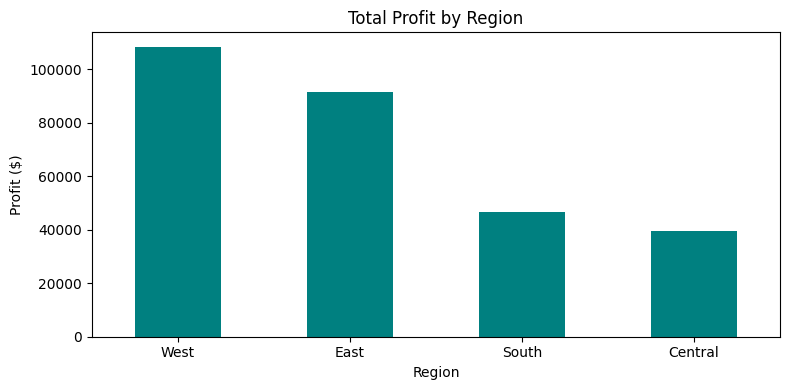

In [4]:
profit_by_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print(profit_by_region)

profit_by_region.plot(kind='bar', color='teal', figsize=(8, 4))
plt.title('Total Profit by Region')
plt.ylabel('Profit ($)')
plt.xlabel('Region')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/profit_by_region.png')
plt.show()

## Sales Heatmap: Category vs Sub-Category

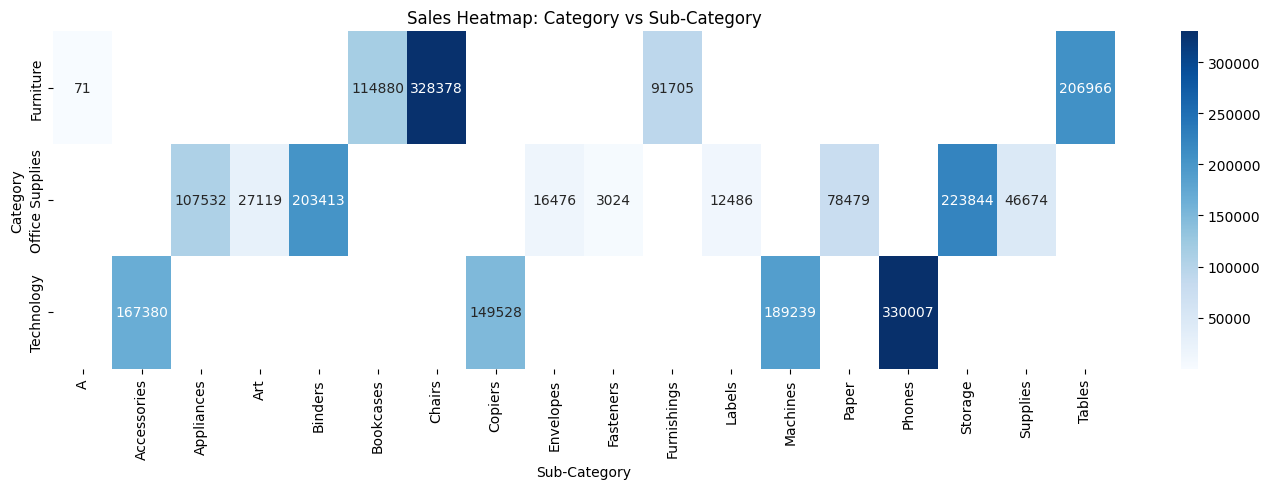

In [5]:
pivot = df.pivot_table(values='Sales', index='Category', columns='Sub-Category', aggfunc='sum')

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues')
plt.title('Sales Heatmap: Category vs Sub-Category')
plt.tight_layout()
plt.savefig('outputs/heatmap.png')
plt.show()

## Top 10 Products by Profit

Product Name
Zebra ZM400 Thermal Label Printer                                               3343.5360
Ibico EPK-21 Electric Binding System                                            3345.2823
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Canon PC1060 Personal Laser Copier                                              4570.9347
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Name: Profit, dtype: float64


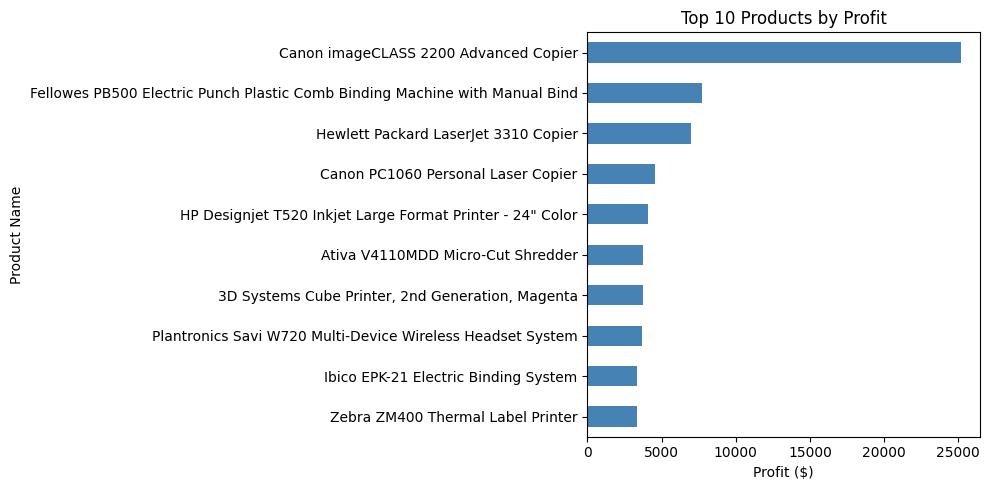

In [6]:
top10 = df.groupby('Product Name')['Profit'].sum().nlargest(10).sort_values()
print(top10)

top10.plot(kind='barh', figsize=(10, 5), color='steelblue')
plt.title('Top 10 Products by Profit')
plt.xlabel('Profit ($)')
plt.ylabel('Product Name')
plt.tight_layout()
plt.savefig('outputs/top10_products.png')
plt.show()